Saving Netflix Dataset (5).xlsx to Netflix Dataset (5) (4).xlsx
✅ Dataset Loaded Successfully
Records: 7789
Years Covered: 2008 → 2021


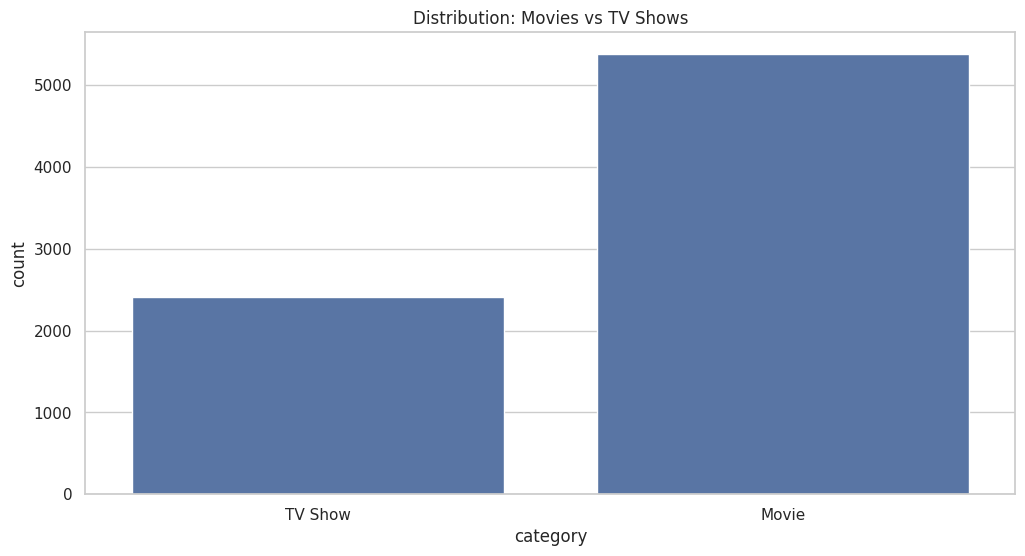

/tmp/ipython-input-3076691490.py:71: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




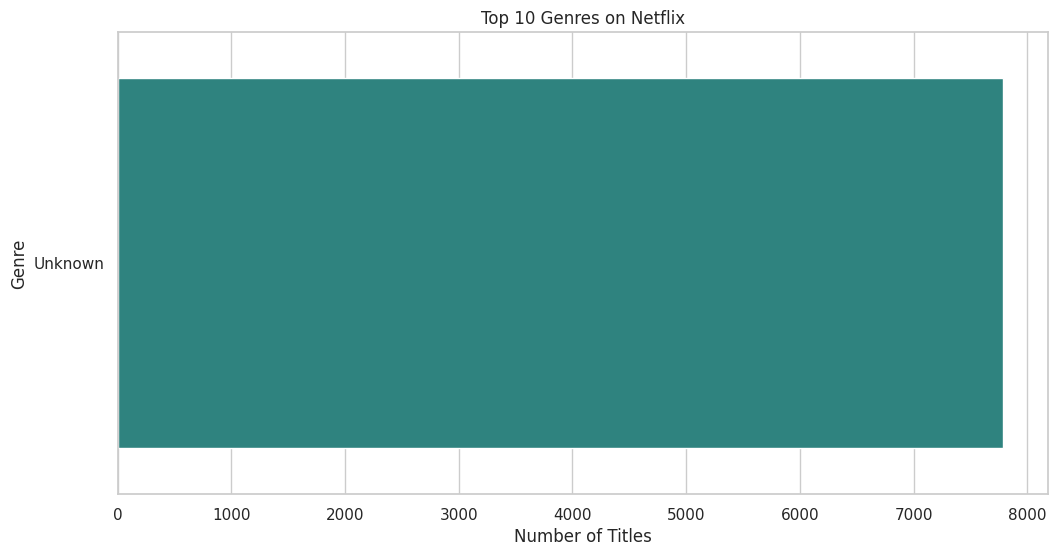

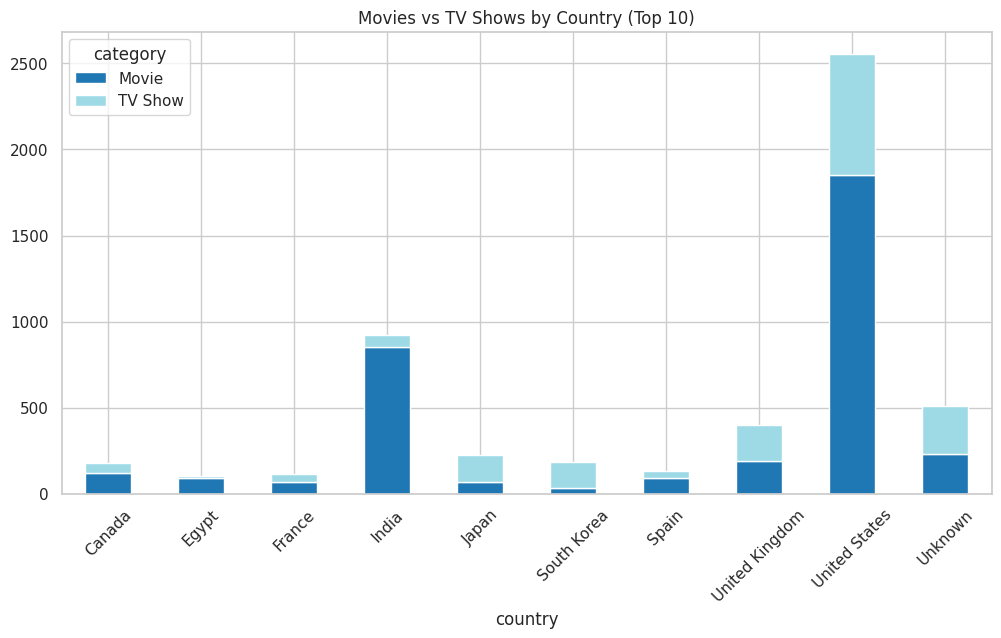

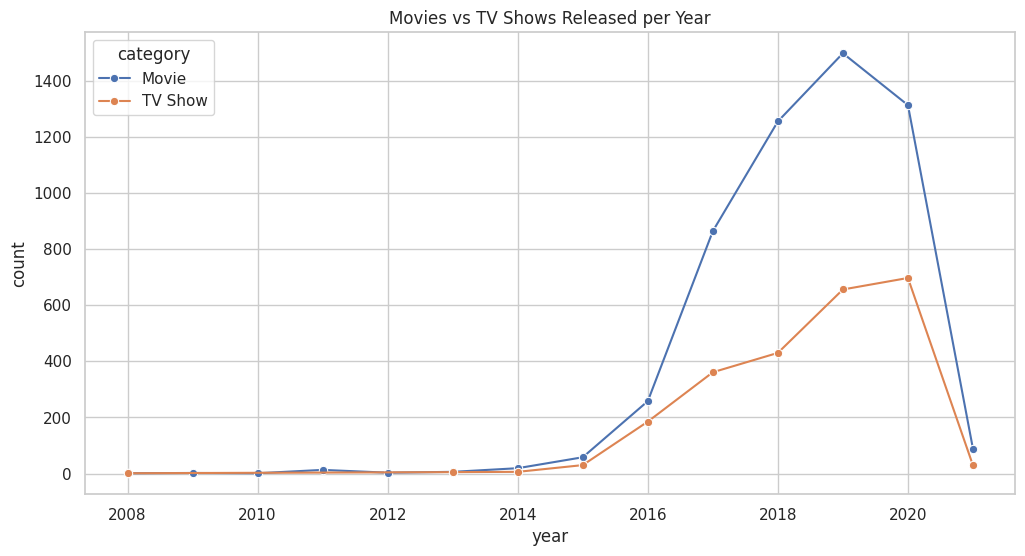

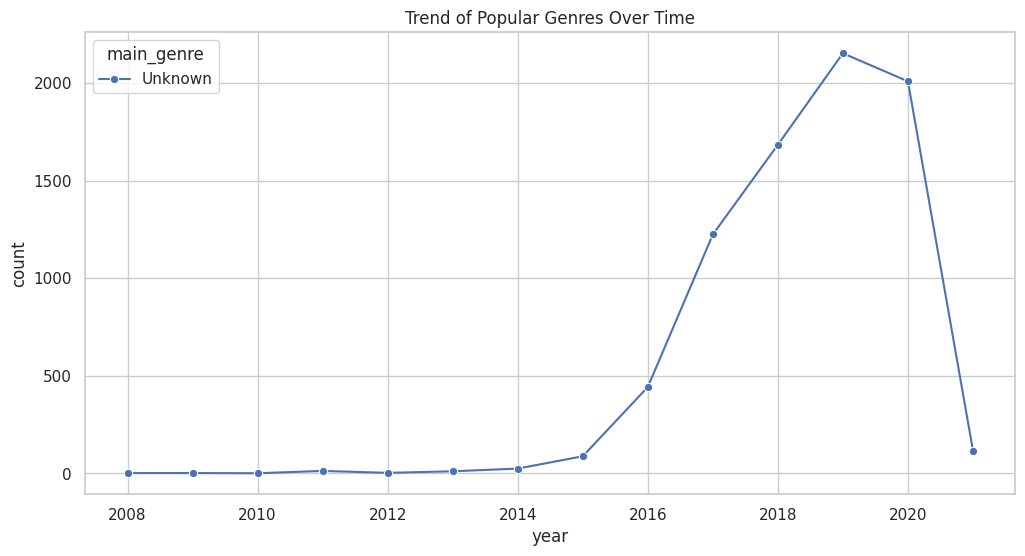


📈 Year-over-Year Growth (%)

category  Movie  TV Show  Total
year                           
2012.0    -77.0      NaN  -77.0
2013.0    100.0      inf  267.0
2014.0    217.0     20.0  127.0
2015.0    205.0    400.0  252.0
2016.0    345.0    517.0  403.0
2017.0    235.0     95.0  177.0
2018.0     45.0     19.0   38.0
2019.0     19.0     53.0   28.0
2020.0    -12.0      6.0   -7.0
2021.0    -93.0    -96.0  -94.0


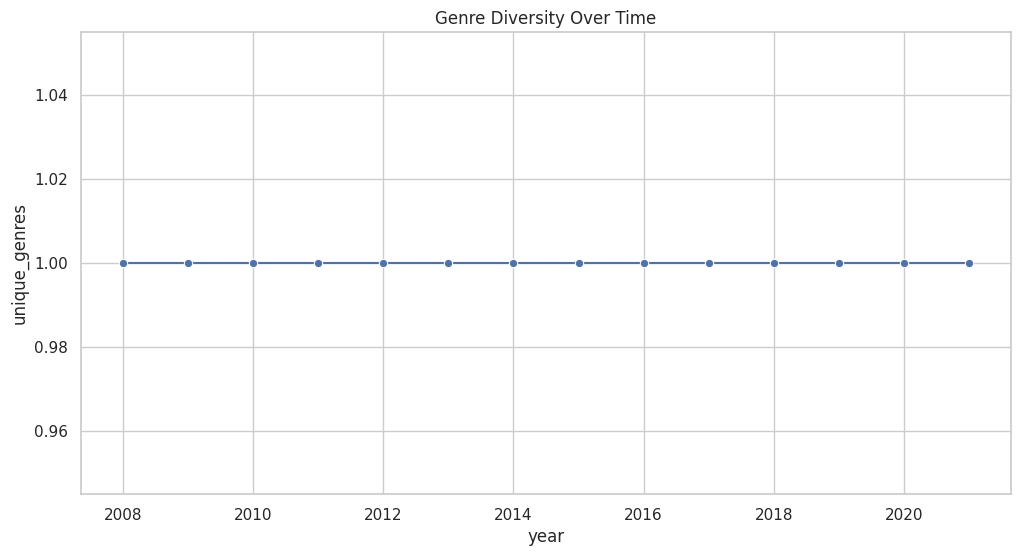

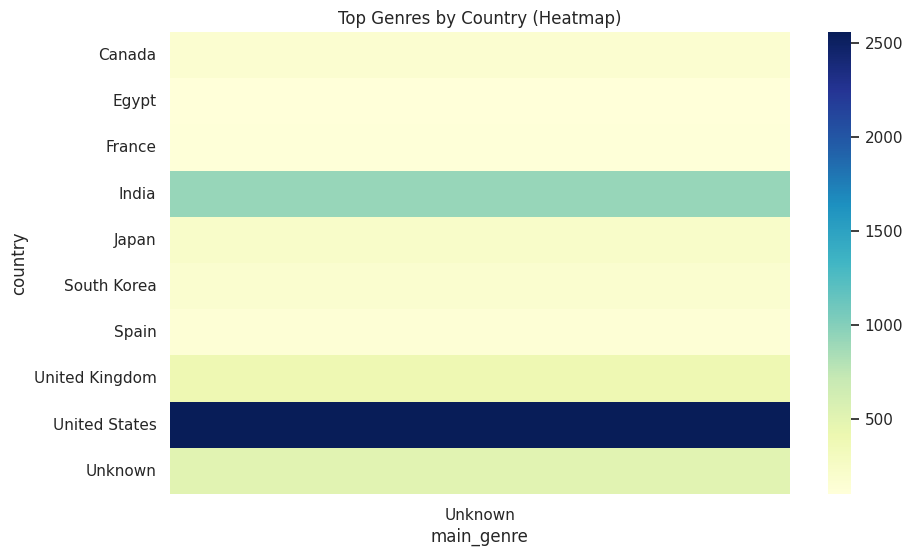


🔗 Correlation between Categories
 category     Movie   TV Show
category                    
Movie     1.000000  0.979527
TV Show   0.979527  1.000000

==================== INSIGHTS ====================

- 🎬 The most common genre overall is **Unknown**.
- 📊 **Movies** have shown higher average growth over recent years.
- 🌍 The highest content contribution comes from **United States**.

==================== STRATEGIC RECOMMENDATIONS ====================

- 🧠 Increase investment in emerging genres like Documentaries and International Dramas.
- 🌏 Strengthen regional content production, especially in India, Korea, and Japan.
- 🎞 Balance between Movies and TV Shows to maintain steady growth across both categories.
- 📺 Focus on cross-genre collaborations (e.g., Comedy-Dramas) to attract diverse audiences.

✅ Analysis Completed. Cleaned dataset saved as 'Netflix_Analysis_Final.xlsx'.


In [5]:
!pip -q install plotly openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files
import io

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# ------------------------------
# Upload Dataset
# ------------------------------
uploaded = files.upload()
if len(uploaded) == 0:
    raise SystemExit("Upload the Excel file and re-run.")
fname = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[fname]))

# ------------------------------
# Data Cleaning
# ------------------------------
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

def colpick(options):
    for o in options:
        if o in df.columns:
            return o
    return None

release_col = colpick(['release_date','date_added','year'])
category_col = colpick(['category','type'])
country_col = colpick(['country'])
genre_col = colpick(['listed_in','genre','genres'])
director_col = colpick(['director'])
cast_col = colpick(['cast'])
rating_col = colpick(['rating'])
title_col = colpick(['title','name'])

df['release_date'] = pd.to_datetime(df.get(release_col), errors='coerce')
df['year'] = df['release_date'].dt.year
df['director'] = df.get(director_col, pd.Series(["Unknown"]*len(df))).fillna("Unknown")
df['cast'] = df.get(cast_col, pd.Series(["Unknown"]*len(df))).fillna("Unknown")
df['country'] = df.get(country_col, pd.Series(["Unknown"]*len(df))).fillna("Unknown")
df['rating'] = df.get(rating_col, pd.Series(["Not Rated"]*len(df))).fillna("Not Rated")
df['category'] = df.get(category_col, pd.Series(["Unknown"]*len(df))).fillna("Unknown")

# ✅ Fix for the 'str' object has no attribute 'apply' error
if genre_col and genre_col in df.columns:
    df['main_genre'] = df[genre_col].apply(lambda x: x.split(",")[0].strip() if isinstance(x, str) else "Unknown")
else:
    df['main_genre'] = "Unknown"

print("✅ Dataset Loaded Successfully")
print("Records:", df.shape[0])
print("Years Covered:", int(df['year'].min()), "→", int(df['year'].max()))

# ------------------------------
# Exploratory Analysis
# ------------------------------
plt.figure()
sns.countplot(x='category', data=df)
plt.title("Distribution: Movies vs TV Shows")
plt.show()

top_genres = df['main_genre'].value_counts().head(10)
plt.figure()
sns.barplot(x=top_genres.values, y=top_genres.index, palette="viridis")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

top_countries = df['country'].value_counts().head(10).index
country_data = df[df['country'].isin(top_countries)]
stacked = country_data.groupby(['country', 'category']).size().unstack(fill_value=0)
stacked.plot(kind='bar', stacked=True, figsize=(12,6), colormap="tab20")
plt.title("Movies vs TV Shows by Country (Top 10)")
plt.xticks(rotation=45)
plt.show()

country_counts = df['country'].value_counts().reset_index()
country_counts.columns = ['Country', 'Count']
fig = px.choropleth(country_counts, locations="Country", locationmode="country names",
                    color="Count", hover_name="Country",
                    color_continuous_scale="viridis", title="Netflix Content by Country")
fig.show()

content_trend = df.groupby(['year','category']).size().reset_index(name='count')
sns.lineplot(data=content_trend, x='year', y='count', hue='category', marker='o')
plt.title("Movies vs TV Shows Released per Year")
plt.show()

popular_genres = df['main_genre'].value_counts().head(5).index
genre_trends = df[df['main_genre'].isin(popular_genres)].groupby(['year','main_genre']).size().reset_index(name='count')
sns.lineplot(data=genre_trends, x='year', y='count', hue='main_genre', marker="o")
plt.title("Trend of Popular Genres Over Time")
plt.show()

# ------------------------------
# Deep Analysis
# ------------------------------

# 1. Year-over-Year Growth
growth = content_trend.pivot(index='year', columns='category', values='count').fillna(0)
growth['Total'] = growth.sum(axis=1)
growth_pct = growth.pct_change().round(2) * 100
print("\n📈 Year-over-Year Growth (%)\n")
print(growth_pct.tail(10))

# 2. Genre Diversity Over Time
genre_diversity = df.groupby('year')['main_genre'].nunique().reset_index(name='unique_genres')
sns.lineplot(data=genre_diversity, x='year', y='unique_genres', marker='o')
plt.title("Genre Diversity Over Time")
plt.show()

# 3. Country vs Genre Heatmap (Top 8 countries)
pivot = df[df['country'].isin(top_countries)].pivot_table(index='country', columns='main_genre', values=title_col or 'country', aggfunc='count', fill_value=0)
top_genres_for_heatmap = pivot.sum().sort_values(ascending=False).head(8).index
plt.figure(figsize=(10,6))
sns.heatmap(pivot[top_genres_for_heatmap], cmap='YlGnBu')
plt.title("Top Genres by Country (Heatmap)")
plt.show()

# 4. Category Correlation with Year
cat_pivot = content_trend.pivot(index='year', columns='category', values='count').fillna(0)
corr = cat_pivot.corr()
print("\n🔗 Correlation between Categories\n", corr)

# ------------------------------
# Insights & Recommendations
# ------------------------------
insights = []

# Most frequent genre
top_genre = df['main_genre'].value_counts().idxmax()
insights.append(f"🎬 The most common genre overall is **{top_genre}**.")

# Fastest growing category
recent_growth = growth_pct.tail(5).mean()
if 'Movie' in recent_growth.index and 'TV Show' in recent_growth.index:
    faster = "Movies" if recent_growth['Movie'] > recent_growth['TV Show'] else "TV Shows"
    insights.append(f"📊 **{faster}** have shown higher average growth over recent years.")

# Country dominance
top_country = df['country'].value_counts().idxmax()
insights.append(f"🌍 The highest content contribution comes from **{top_country}**.")

# Genre diversity
if genre_diversity['unique_genres'].iloc[-1] > genre_diversity['unique_genres'].iloc[0]:
    insights.append("📈 Netflix’s genre diversity has expanded steadily over the years.")

# Strategic Recommendations
recommendations = [
    "🧠 Increase investment in emerging genres like Documentaries and International Dramas.",
    "🌏 Strengthen regional content production, especially in India, Korea, and Japan.",
    "🎞 Balance between Movies and TV Shows to maintain steady growth across both categories.",
    "📺 Focus on cross-genre collaborations (e.g., Comedy-Dramas) to attract diverse audiences."
]

print("\n==================== INSIGHTS ====================\n")
for i in insights:
    print("-", i)

print("\n==================== STRATEGIC RECOMMENDATIONS ====================\n")
for r in recommendations:
    print("-", r)

# Save cleaned dataset
df.to_excel("Netflix_Analysis_Final.xlsx", index=False)
print("\n✅ Analysis Completed. Cleaned dataset saved as 'Netflix_Analysis_Final.xlsx'.")
